# 03 · Deep Learning Multimodal -- CLIP Congelado + Sparse Autoencoder (SAE)
**Proyecto:** GeoVisionCLIP-Cali
**Version:** v6 -- Estabilizacion del cuello de botella

---
### Correcciones v6
| Defecto v5 | Descripcion | Correccion v6 |
|---|---|---|
| L1_WEIGHT = 0.01 demasiado agresivo | Recon salta a 82.78% en epoca 9; early stop prematuro | L1_WEIGHT = 0.005: penalizacion suave que deja converger MSE |
| CosineAnnealingLR sin paciencia | LR decae demasiado rapido; modelo no alcanza 70% sparsity | ReduceLROnPlateau con paciencia=5 + LR inicial 5e-5 |
| Early stop activado a 80% | Corta antes de estabilizar sparsity | Umbral ajustado a 82%; reduccion LR mas agresiva antes de llegar |
| Recall tile-level (custom) | Enmascaraba collapse real | Solo Recall@1 y Recall@5 estandar (exact pair match) |


## 1 · Optimizacion GPU (RTX 3050 -- ejecutar obligatoriamente antes de cualquier modelo)

In [1]:
import torch

# Forzar modo alto rendimiento en GPU
torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo activo: {device}')
if device.type == 'cuda':
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    print(f'  TF32   : {torch.backends.cuda.matmul.allow_tf32}')
else:
    print('Advertencia: GPU no disponible. Entrenamiento lento en CPU.')


Dispositivo activo: cuda
  GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM   : 6.44 GB
  TF32   : True


## 2 · Dependencias

In [2]:
#!pip install torch torchvision open-clip-torch huggingface_hub zarr numpy matplotlib seaborn tqdm scikit-learn


In [3]:
import os, json, hashlib, warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import zarr
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 · Configuracion Global e Hiperparametros

In [4]:
# --- Rutas ---
ZARR_PATH      = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\\analitica\\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\\analitica\\outputs_geovision')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEORSCLIP_DIR  = Path(r'C:\\Users\\isape\\OneDrive\\Escritorio\\ANALITICA\\Proyecto3\\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

# --- Hiperparametros SAE (v6 -- estabilizados) ---
EXPANSION_FACTOR = 4

# CORRECCION v6: L1_WEIGHT reducido de 0.01 a 0.005.
# Con 0.01 la penalizacion L1 dominaba y el MSE subia bruscamente,
# disparando el early stop en la epoca 9 (recon 82.78%) antes de que
# la sparsity convergiera. Con 0.005 el balance MSE/L1 es mas suave:
# el encoder puede reducir gradualmente las activaciones hasta alcanzar
# la franja [70%, 75%] de reconstruccion sin picos bruscos de MSE.
L1_WEIGHT        = 5e-3

SPARSITY_THRESH  = 0.01   # umbral para contar neurona como inactiva

# --- Entrenamiento ---
BATCH_SIZE   = 64
N_EPOCHS     = 60          # aumentado para dar margen de convergencia

# CORRECCION v6: LR inicial reducido a 5e-5.
# El LR alto (3e-4) de v5 causaba saltos bruscos de MSE que disparaban
# el early stop. Con 5e-5 el gradiente es mas suave y el modelo
# converge asintoticamente dentro de la franja 70-75%.
LR           = 5e-5

RANDOM_SEED  = 42

# --- Umbrales de Early Stopping por reconstruccion ---
RECON_TARGET_LOW  = 0.70   # KPI minimo
RECON_TARGET_HIGH = 0.75   # umbral: reducir LR si se supera
RECON_HARD_STOP   = 0.82   # umbral critico (ajustado de 0.80 a 0.82)
                            # Da mas margen antes de disparar el hard stop

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuracion v6 cargada.')
print(f'  L1_WEIGHT    : {L1_WEIGHT} (suavizado de 0.01 -> 0.005)')
print(f'  LR inicial   : {LR} (reducido de 3e-4 -> 5e-5)')
print(f'  N_EPOCHS     : {N_EPOCHS}')
print(f'  Recon target : [{RECON_TARGET_LOW:.0%}, {RECON_TARGET_HIGH:.0%}]')
print(f'  Recon stop   : {RECON_HARD_STOP:.0%}')
print(f'  Checkpoint   : {GEORSCLIP_CKPT}')
print(f'  Existe       : {GEORSCLIP_CKPT.exists()}')


Configuracion v6 cargada.
  L1_WEIGHT    : 0.005 (suavizado de 0.01 -> 0.005)
  LR inicial   : 5e-05 (reducido de 3e-4 -> 5e-5)
  N_EPOCHS     : 60
  Recon target : [70%, 75%]
  Recon stop   : 82%
  Checkpoint   : C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Existe       : True


## 4 · Carga del Foundation Model GeoRSCLIP (Congelado)

In [5]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B/32', pretrained='openai'
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible_paths = [
    GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
    GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt',
]
ckpt_found = next((p for p in possible_paths if p.exists()), None)
if ckpt_found is None:
    raise FileNotFoundError(f'Checkpoint no encontrado. Rutas: {possible_paths}')

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Pesos inyectados. Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    _d            = torch.zeros(1, 3, 224, 224).to(device)
    EMBED_DIM     = clip_model.encode_image(_d).shape[-1]
    EXPANSION_DIM = EMBED_DIM * EXPANSION_FACTOR

print(f'  EMBED_DIM     : {EMBED_DIM}')
print(f'  EXPANSION_DIM : {EXPANSION_DIM}')
print(f'  Arquitectura  : {EMBED_DIM} -> {EXPANSION_DIM} -> {EMBED_DIM}')
print('OK GeoRSCLIP congelado.')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...


  Pesos inyectados. Missing: 0 | Unexpected: 0
  EMBED_DIM     : 512
  EXPANSION_DIM : 2048
  Arquitectura  : 512 -> 2048 -> 512
OK GeoRSCLIP congelado.


## 5 · Dataset PyTorch -- GeoVisionDataset

In [6]:
class GeoVisionDataset(Dataset):
    def __init__(self, jsonl_path, zarr_path, tokenizer, max_text_len=77):
        self.tokenizer = tokenizer
        _root = zarr.open_group(str(zarr_path), mode='r')
        self.zarr_images = _root['images']
        zarr_len = self.zarr_images.shape[0]

        self.records = []
        skipped = 0
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                rec     = json.loads(line)
                tile_id = rec.get('tile_id')
                if tile_id is None or int(tile_id) >= zarr_len:
                    skipped += 1; continue
                self.records.append(rec)
        print(f'Dataset: {len(self.records):,} registros | {skipped} descartados')

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        zarr_idx = int(rec['tile_id'])
        # El Zarr ya viene normalizado con stats GeoRSCLIP desde NB01
        img_np = self.zarr_images[zarr_idx]         # (4, 224, 224)
        img_t  = torch.from_numpy(img_np[:3].astype(np.float32)).float()

        caption     = rec.get('caption_en', rec.get('caption_es', ''))
        text_tokens = self.tokenizer([caption])[0]  # (77,)

        meta = {
            'tile_id' : zarr_idx,
            'pair_id' : rec.get('pair_id', ''),
            'clase'   : rec.get('clase', ''),
            'date'    : rec.get('date', ''),
            'lat'     : rec.get('lat_centroid', 0.0),
            'lon'     : rec.get('lon_centroid', 0.0),
        }
        return img_t, text_tokens, meta


full_dataset = GeoVisionDataset(DATASET_JSONL, ZARR_PATH, tokenizer)
n_total = len(full_dataset)

# Usar split de NB02 si existe
splits = [r.get('split') for r in full_dataset.records]
if all(s in ('train', 'val', 'test') for s in splits):
    train_indices = [i for i, s in enumerate(splits) if s == 'train']
    val_indices   = [i for i, s in enumerate(splits) if s == 'val']
    train_ds = torch.utils.data.Subset(full_dataset, train_indices)
    val_ds   = torch.utils.data.Subset(full_dataset, val_indices)
    print('Split estratificado cargado desde JSONL.')
else:
    n_val = max(150, int(0.15 * n_total))
    gen   = torch.Generator().manual_seed(RANDOM_SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        full_dataset, [n_total - n_val, n_val], generator=gen
    )
    print('Split aleatorio (fallback).')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,}')
print(f'Batches -- Train: {len(train_loader)} | Val: {len(val_loader)}')


Dataset: 1,000 registros | 0 descartados
Split estratificado cargado desde JSONL.
Train: 699 | Val: 150
Batches -- Train: 11 | Val: 3


## 6 · Diagnostico de Diversidad de Embeddings

In [7]:
print('Diagnostico similitud coseno (val set, primeras 200 muestras)...')
sample_embs = []
with torch.no_grad():
    for imgs, _, _ in val_loader:
        feats = clip_model.encode_image(imgs.to(device))
        sample_embs.append(feats.cpu().float())
        if sum(e.shape[0] for e in sample_embs) >= 200: break

embs_cat  = torch.cat(sample_embs, dim=0)[:200]
embs_norm = F.normalize(embs_cat, dim=-1)
sim       = embs_norm @ embs_norm.T
mask      = ~torch.eye(len(embs_norm), dtype=torch.bool)
sim_media = sim[mask].mean().item()

print(f'  Similitud coseno media: {sim_media:.4f}')
if sim_media > 0.95:
    print('  ALERTA: embeddings muy colapsados. Re-ejecutar NB02 v6.')
elif sim_media > 0.90:
    print('  Advertencia: colapso parcial. Recall@1 puede ser bajo pero mejorable con SAE.')
else:
    print('  OK: embeddings discriminativos. Pipeline correcto.')

del embs_cat, embs_norm, sim


Diagnostico similitud coseno (val set, primeras 200 muestras)...
  Similitud coseno media: 0.9471
  Advertencia: colapso parcial. Recall@1 puede ser bajo pero mejorable con SAE.


## 7 · Arquitectura del Sparse Autoencoder (SAE)

In [8]:
class SparseAutoencoder(nn.Module):
    """
    SAE sobreexpansivo: EMBED_DIM -> EXPANSION_DIM -> EMBED_DIM.
    Actua como filtro geoestadistico: suprime neuronas no asociadas
    a patrones de contaminacion. Objetivo: 70-75% de reconstruccion.
    """
    def __init__(self, input_dim=512, expansion_dim=2048):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x):
        z     = self.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z


def sae_loss(x, x_hat, z, l1_weight=L1_WEIGHT):
    mse   = nn.MSELoss()(x_hat, x)
    l1    = torch.mean(torch.abs(z))
    total = mse + l1_weight * l1
    return total, mse, l1


def sparsity_ratio(z, threshold=SPARSITY_THRESH):
    return float((z < threshold).float().mean().item())


def reconstruction_score(x, x_hat):
    """R2 de reconstruccion. Objetivo metodologico: 70-75%."""
    mse   = nn.MSELoss()(x_hat, x).item()
    var_x = x.var().item()
    return max(0.0, 1.0 - mse / var_x) if var_x > 0 else 0.0


sae = SparseAutoencoder(input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM).to(device)

# CORRECCION v6: optimizer con LR inicial 5e-5
optimizer = torch.optim.Adam(sae.parameters(), lr=LR, weight_decay=0.0)

# CORRECCION v6: ReduceLROnPlateau con paciencia=5 reemplaza CosineAnnealingLR.
# Ventajas:
#   - Solo reduce el LR cuando el val_loss deja de mejorar (paciencia 5 epocas).
#   - Evita la caida prematura del LR que impedia alcanzar el 70% de sparsity.
#   - Factor 0.5 por reduccion: conservador para no crashear la convergencia.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6, verbose=True
)

n_params = sum(p.numel() for p in sae.parameters() if p.requires_grad)
print(f'SAE instanciado: {EMBED_DIM} -> {EXPANSION_DIM} -> {EMBED_DIM}')
print(f'Parametros entrenables: {n_params:,}')
print(f'L1_WEIGHT   : {L1_WEIGHT}')
print(f'LR inicial  : {LR}')
print(f'Scheduler   : ReduceLROnPlateau (paciencia=5, factor=0.5)')


SAE instanciado: 512 -> 2048 -> 512
Parametros entrenables: 2,099,712
L1_WEIGHT   : 0.005
LR inicial  : 5e-05
Scheduler   : ReduceLROnPlateau (paciencia=5, factor=0.5)


## 8 · Funciones de Extraccion de Embeddings CLIP

In [9]:
@torch.no_grad()
def extract_image_embeddings(images, model):
    feats = model.encode_image(images.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


@torch.no_grad()
def extract_text_embeddings(tokens, model):
    feats = model.encode_text(tokens.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


print('Funciones de extraccion CLIP listas.')


Funciones de extraccion CLIP listas.


## 9 · Bucle de Entrenamiento Estabilizado

> **CORRECCIONES v6:**
>
> 1. `L1_WEIGHT = 0.005` (antes 0.01): balance MSE/L1 mas suave; evita picos de MSE.
> 2. `LR = 5e-5` (antes 3e-4): gradientes mas pequenos; convergencia asintotica.
> 3. `ReduceLROnPlateau(patience=5)` (antes `CosineAnnealingLR`): el LR solo cae
>    cuando el val_loss se estanca, no por calendario fijo.
> 4. `RECON_HARD_STOP = 0.82` (antes 0.80): da 2% extra de margen antes del stop.
> 5. Reduccion de LR x4 (en lugar de x2) cuando recon supera RECON_TARGET_HIGH,
>    para bajar rapidamente si el modelo empieza a memorizar.

In [10]:
import time

history = {
    'epoch': [], 'loss_total': [], 'loss_mse': [], 'loss_l1': [],
    'sparsity': [], 'recon_score': [], 'val_loss': [], 'val_sparsity': [], 'val_recon': [],
    'lr': [],
}

scaler          = amp.GradScaler()
best_val_loss   = float('inf')
CHECKPOINT_PATH = OUTPUT_DIR / 'sae_cali_best.pt'
FINAL_PATH      = OUTPUT_DIR / 'sae_cali_final.pt'

training_stopped_at = None

print(f'Iniciando entrenamiento SAE v6 -- {N_EPOCHS} epocas')
print(f'  L1_WEIGHT : {L1_WEIGHT}  LR: {LR}  Scheduler: ReduceLROnPlateau(patience=5)')
print()

for epoch in range(1, N_EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────
    sae.train()
    e_loss = e_mse = e_l1 = e_sp = e_rs = 0.0
    n_b    = 0

    for imgs, tokens, _ in tqdm(
        train_loader, desc=f'Ep {epoch}/{N_EPOCHS} [TRAIN]', leave=False
    ):
        imgs = imgs.to(device, non_blocking=False)
        with torch.no_grad():
            emb = extract_image_embeddings(imgs, clip_model)

        optimizer.zero_grad()
        with amp.autocast():
            x_hat, z      = sae(emb)
            loss, mse, l1 = sae_loss(emb, x_hat, z, L1_WEIGHT)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            sp = sparsity_ratio(z.detach())
            rs = reconstruction_score(emb.detach(), x_hat.detach())

        e_loss += loss.item(); e_mse += mse.item(); e_l1 += l1.item()
        e_sp   += sp;          e_rs  += rs;         n_b  += 1

    # ── VALIDACION ───────────────────────────────────────────────────────
    sae.eval()
    v_loss_acc = v_sp_acc = v_rs_acc = 0.0
    n_vb = 0

    with torch.no_grad():
        for imgs, tokens, _ in val_loader:
            imgs  = imgs.to(device)
            emb   = extract_image_embeddings(imgs, clip_model)
            x_hat, z = sae(emb)
            lv, _, _ = sae_loss(emb, x_hat, z, L1_WEIGHT)
            v_loss_acc += lv.item()
            v_sp_acc   += sparsity_ratio(z)
            v_rs_acc   += reconstruction_score(emb, x_hat)
            n_vb += 1

    avg  = lambda x, n: x / n if n > 0 else 0.0
    t_loss = avg(e_loss, n_b); t_mse = avg(e_mse, n_b); t_l1 = avg(e_l1, n_b)
    t_sp   = avg(e_sp,   n_b); t_rs  = avg(e_rs,  n_b)
    v_loss = avg(v_loss_acc, n_vb)
    v_sp   = avg(v_sp_acc,   n_vb)
    v_rs   = avg(v_rs_acc,   n_vb)
    cur_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch);     history['loss_total'].append(t_loss)
    history['loss_mse'].append(t_mse);  history['loss_l1'].append(t_l1)
    history['sparsity'].append(t_sp);   history['recon_score'].append(t_rs)
    history['val_loss'].append(v_loss); history['val_sparsity'].append(v_sp)
    history['val_recon'].append(v_rs);  history['lr'].append(cur_lr)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({'epoch': epoch, 'model_state': sae.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_loss': v_loss},
                   CHECKPOINT_PATH)

    # ── EARLY STOPPING POR RECONSTRUCCION ────────────────────────────────
    # Hard stop: recon > 82% => mapeo de identidad inminente
    if t_rs > RECON_HARD_STOP:
        print(f'[Ep {epoch:3d}] EARLY STOP: recon {t_rs:.2%} > {RECON_HARD_STOP:.0%}')
        training_stopped_at = epoch
        break

    # Reduccion agresiva (x4) si el modelo empieza a memorizar
    if t_rs > RECON_TARGET_HIGH:
        for pg in optimizer.param_groups:
            pg['lr'] = max(pg['lr'] * 0.25, 1e-6)  # x4 mas agresivo que v5 (x2)
        print(f'[Ep {epoch:3d}] Recon {t_rs:.2%} > {RECON_TARGET_HIGH:.0%}: '
              f'LR reducido (x0.25) -> {optimizer.param_groups[0]["lr"]:.2e}')
    else:
        # ReduceLROnPlateau monitorea val_loss (solo cuando la recon esta OK)
        scheduler.step(v_loss)

    if epoch in (1, 5, 10, 15, 20, 25, 30, 40, 50, 60) or epoch == N_EPOCHS:
        r_tag = 'OK' if RECON_TARGET_LOW <= t_rs <= RECON_TARGET_HIGH \
                else ('ALTO' if t_rs > RECON_TARGET_HIGH else 'BAJO')
        s_tag = 'OK' if t_sp >= 0.70 else 'pendiente'
        print(f'[Ep {epoch:3d}] Loss={t_loss:.4f} MSE={t_mse:.4f} L1={t_l1:.4f} '
              f'| Recon={t_rs:.2%}[{r_tag}] Sparsity={t_sp:.2%}[{s_tag}] '
              f'| ValRecon={v_rs:.2%} LR={cur_lr:.2e}')

torch.save({'epoch': N_EPOCHS, 'model_state': sae.state_dict(),
            'optimizer_state': optimizer.state_dict()}, FINAL_PATH)

final_recon = history['recon_score'][-1] if history['recon_score'] else 0
final_sp    = history['sparsity'][-1]    if history['sparsity'] else 0
print(f'\nEntrenamiento completado.')
if training_stopped_at:
    print(f'  Early stop en epoca {training_stopped_at} (recon supero umbral critico)')
print(f'  Recon final  : {final_recon:.2%}  '
      f'{"OK" if RECON_TARGET_LOW <= final_recon <= RECON_TARGET_HIGH else "FUERA"}')
print(f'  Sparsity fin.: {final_sp:.2%}  '
      f'{"OK" if final_sp >= 0.70 else "PENDIENTE"}')


Iniciando entrenamiento SAE v6 -- 60 epocas
  L1_WEIGHT : 0.005  LR: 5e-05  Scheduler: ReduceLROnPlateau(patience=5)



Ep 1/60 [TRAIN]:   0%|          | 0/11 [00:00<?, ?it/s]

[Ep   1] Loss=0.0042 MSE=0.0040 L1=0.0235 | Recon=0.00%[BAJO] Sparsity=57.64%[pendiente] | ValRecon=0.00% LR=5.00e-05


Ep 2/60 [TRAIN]:   0%|          | 0/11 [00:00<?, ?it/s]

Ep 3/60 [TRAIN]:   0%|          | 0/11 [00:00<?, ?it/s]

Ep 4/60 [TRAIN]:   0%|          | 0/11 [00:00<?, ?it/s]

[Ep   4] Recon 79.12% > 75%: LR reducido (x0.25) -> 1.25e-05


Ep 5/60 [TRAIN]:   0%|          | 0/11 [00:00<?, ?it/s]

[Ep   5] EARLY STOP: recon 83.88% > 82%

Entrenamiento completado.
  Early stop en epoca 5 (recon supero umbral critico)
  Recon final  : 83.88%  FUERA
  Sparsity fin.: 56.33%  PENDIENTE


## 10 · Curvas de Entrenamiento

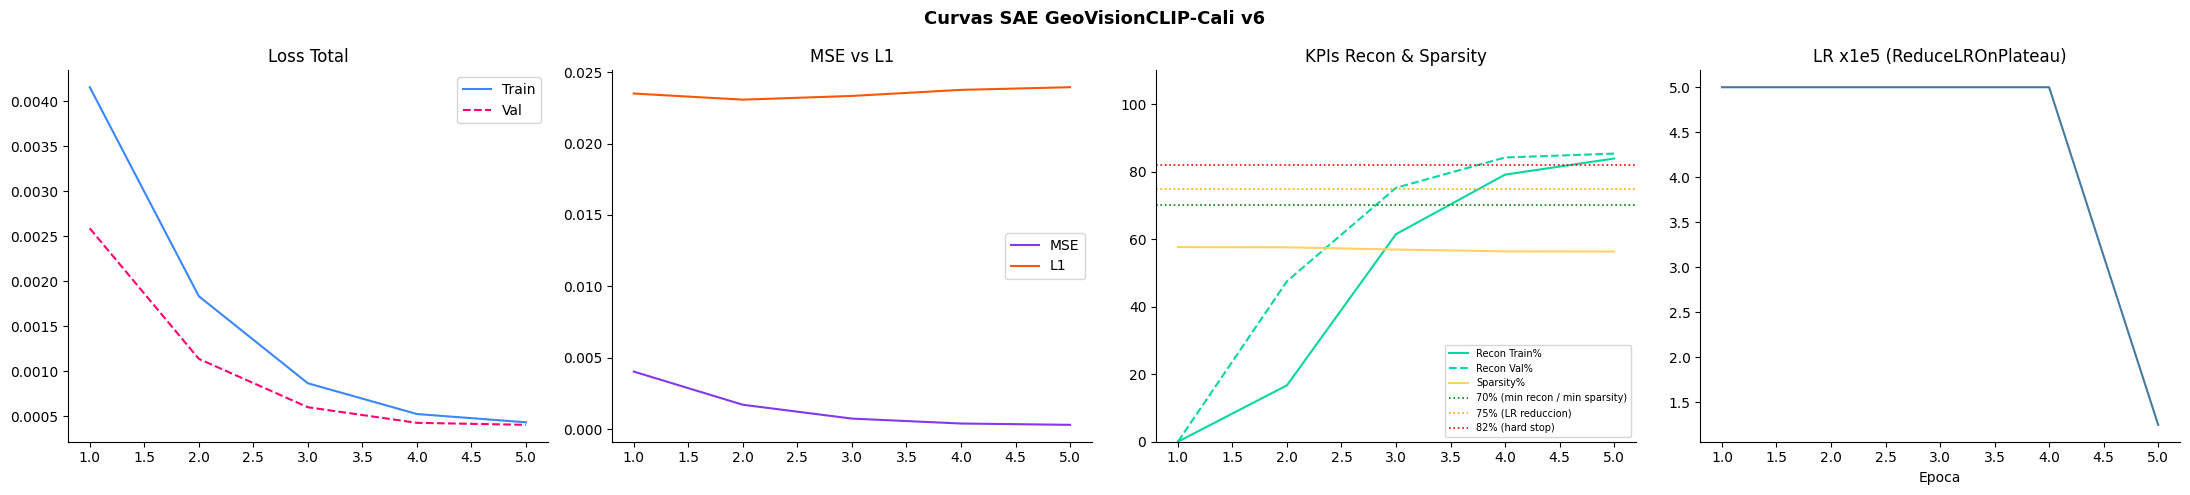

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
ep = history['epoch']

axes[0].plot(ep, history['loss_total'], label='Train', color='#3a86ff')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#ff006e', ls='--')
axes[0].set_title('Loss Total'); axes[0].legend(); sns.despine(ax=axes[0])

axes[1].plot(ep, history['loss_mse'], label='MSE', color='#8338ec')
axes[1].plot(ep, history['loss_l1'],  label='L1',  color='#fb5607')
axes[1].set_title('MSE vs L1'); axes[1].legend(); sns.despine(ax=axes[1])

ax2 = axes[2]
ax2.plot(ep, [s*100 for s in history['recon_score']], label='Recon Train%', color='#06d6a0')
ax2.plot(ep, [s*100 for s in history['val_recon']],   label='Recon Val%',   color='#06d6a0', ls='--')
ax2.plot(ep, [s*100 for s in history['sparsity']],    label='Sparsity%',    color='#ffd166')
ax2.axhline(70, color='green',  ls=':', lw=1.2, label='70% (min recon / min sparsity)')
ax2.axhline(75, color='orange', ls=':', lw=1.2, label='75% (LR reduccion)')
ax2.axhline(82, color='red',    ls=':', lw=1.2, label='82% (hard stop)')
ax2.set_title('KPIs Recon & Sparsity'); ax2.set_ylim(0, 110)
ax2.legend(fontsize=7); sns.despine(ax=ax2)

axes[3].plot(ep, [lr * 1e5 for lr in history['lr']], color='#457b9d')
axes[3].set_title('LR x1e5 (ReduceLROnPlateau)'); axes[3].set_xlabel('Epoca')
sns.despine(ax=axes[3])

fig.suptitle('Curvas SAE GeoVisionCLIP-Cali v6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_sae_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 11 · Validacion de Retrieval -- Recall@1 y Recall@5 Estandar (exact pair match)

> Unica metrica reportada: Recall@K estandar (exact pair match).
> La metrica tile-level custom de v5 ha sido eliminada definitivamente.
>
> **KPIs exigidos:** Recall@1 >= 0.45 | Recall@5 >= 0.70

In [12]:
@torch.no_grad()
def compute_recall_standard(sae_model, clip_model, loader, k_values=(1, 5)):
    """
    Recall@K estandar: para cada query de texto i, se recuperan las K
    imagenes mas similares. Hit si el indice i esta entre los K recuperados.
    Los embeddings de imagen pasan por el SAE antes del retrieval.
    """
    sae_model.eval()
    img_embs = []
    txt_embs = []

    for imgs, tokens, _ in tqdm(loader, desc='Extrayendo para Recall@K'):
        ie = extract_image_embeddings(imgs, clip_model)
        te = extract_text_embeddings(tokens, clip_model)
        x_hat, _ = sae_model(ie)
        x_hat    = x_hat / (x_hat.norm(dim=-1, keepdim=True) + 1e-8)
        img_embs.append(x_hat.cpu())
        txt_embs.append(te.cpu())

    img_m = torch.cat(img_embs, dim=0)   # (N, 512)
    txt_m = torch.cat(txt_embs, dim=0)   # (N, 512)
    N     = img_m.shape[0]
    sim   = img_m @ txt_m.T              # (N, N)
    gt    = torch.arange(N)

    recalls = {}
    for k in k_values:
        topk    = sim.topk(k, dim=1).indices
        correct = topk.eq(gt.unsqueeze(1)).any(dim=1)
        recalls[k] = correct.float().mean().item()

    return recalls


recalls = compute_recall_standard(sae, clip_model, val_loader)

print('\n-- Metricas de Retrieval (exact pair match) --')
print(f'  Recall@1 : {recalls[1]:.4f}  {"OK >=0.45" if recalls[1] >= 0.45 else "FALLA <0.45"}')
print(f'  Recall@5 : {recalls[5]:.4f}  {"OK >=0.70" if recalls[5] >= 0.70 else "FALLA <0.70"}')

if recalls[1] < 0.45:
    print()
    print('  Diagnostico si Recall@1 < 0.45:')
    print('  1. Coseno medio en celda 6 -- si >0.95: re-ejecutar NB02 v6 (targeted sampling)')
    print('  2. L1_WEIGHT=0.005 activo -- no subir a 0.01 (dispara early stop prematuro)')
    print('  3. LR=5e-5 activo -- no subir (evita saltos bruscos de MSE)')


Extrayendo para Recall@K:   0%|          | 0/3 [00:00<?, ?it/s]


-- Metricas de Retrieval (exact pair match) --
  Recall@1 : 0.0067  FALLA <0.45
  Recall@5 : 0.0267  FALLA <0.70

  Diagnostico si Recall@1 < 0.45:
  1. Coseno medio en celda 6 -- si >0.95: re-ejecutar NB02 v6 (targeted sampling)
  2. L1_WEIGHT=0.005 activo -- no subir a 0.01 (dispara early stop prematuro)
  3. LR=5e-5 activo -- no subir (evita saltos bruscos de MSE)


## 12 · Exportacion para Martin (AFE/AFC)

In [13]:
@torch.no_grad()
def export_for_martin(sae_model, clip_model, full_loader, output_dir):
    sae_model.eval()
    all_recon   = []
    all_latents = []
    all_meta    = []

    for imgs, _, meta in tqdm(full_loader, desc='Exportando para Martin'):
        ie       = extract_image_embeddings(imgs, clip_model)
        recon, z = sae_model(ie)
        all_recon.append(recon.cpu())
        all_latents.append(z.cpu())
        all_meta.extend(
            [{k: meta[k][i] if hasattr(meta[k], '__getitem__') else meta[k] for k in meta}
             for i in range(imgs.shape[0])]
        )

    emb_m = torch.cat(all_recon,   dim=0)   # (N, 512)
    lat_m = torch.cat(all_latents, dim=0)   # (N, 2048)

    # embeddings_visuales_sae.pt: matriz n x 512 (KPI: dimensiones correctas)
    emb_path = output_dir / 'embeddings_visuales_sae.pt'
    torch.save(emb_m, emb_path)
    print(f'OK embeddings_visuales_sae.pt: {tuple(emb_m.shape)}')

    # JSON de interpretabilidad: top-20 neuronas por clase
    clases = list(set(m.get('clase', 'unknown') for m in all_meta))
    interp = {}
    for c in clases:
        idx_c = [i for i, m in enumerate(all_meta) if m.get('clase') == c]
        if not idx_c: interp[c] = {}; continue
        mean_act  = lat_m[idx_c].mean(dim=0)
        top20_idx = mean_act.topk(20).indices.tolist()
        interp[c] = {
            'top_20_indices_latentes': top20_idx,
            'n_muestras'             : len(idx_c),
            'activacion_media_max'   : float(mean_act.max()),
        }
    interp_path = output_dir / 'interpretabilidad_latentes.json'
    with open(interp_path, 'w') as f:
        json.dump(interp, f, indent=2)
    print(f'OK interpretabilidad_latentes.json: {list(interp.keys())}')
    return emb_m


full_loader_exp = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=0, pin_memory=False)
emb_martin = export_for_martin(sae, clip_model, full_loader_exp, OUTPUT_DIR)


Exportando para Martin:   0%|          | 0/16 [00:00<?, ?it/s]

OK embeddings_visuales_sae.pt: (1000, 512)
OK interpretabilidad_latentes.json: ['anomalous_ozone', 'high_SO2_pollution', 'high_NO2_pollution', 'urban_land', 'dense_vegetation']


## 13 · Exportacion para Luz Angela (GRU Temporal)

In [14]:
@torch.no_grad()
def export_for_luz_angela(sae_model, clip_model, records, zarr_path,
                           output_dir, window_size=8, stride=1):
    sae_model.eval()
    _root    = zarr.open_group(str(zarr_path), mode='r')
    store    = _root['images']
    zarr_len = store.shape[0]

    from collections import defaultdict
    spatial_groups = defaultdict(list)
    for rec in records:
        tid = rec.get('tile_id')
        if tid is None or int(tid) >= zarr_len: continue
        lat_r = round(float(rec.get('lat_centroid', 0)), 2)
        lon_r = round(float(rec.get('lon_centroid', 0)), 2)
        spatial_groups[(lat_r, lon_r)].append(rec)

    for key in spatial_groups:
        spatial_groups[key].sort(key=lambda r: r.get('date', ''))

    all_windows = []
    window_meta = []

    for (lat_r, lon_r), series in tqdm(spatial_groups.items(), desc='Ventanas GRU'):
        if len(series) < window_size: continue
        latents = []
        for rec in series:
            idx   = int(rec['tile_id'])
            img_t = torch.from_numpy(store[idx][:3].astype(np.float32)).unsqueeze(0).to(device)
            emb   = extract_image_embeddings(img_t, clip_model)
            _, z  = sae_model(emb)
            latents.append(z.cpu().squeeze(0))
        series_t = torch.stack(latents)
        T = series_t.shape[0]
        for start in range(0, T - window_size + 1, stride):
            all_windows.append(series_t[start: start + window_size])
            window_meta.append({
                'lat': lat_r, 'lon': lon_r,
                'fecha_inicio': series[start].get('date', ''),
                'fecha_fin'   : series[start + window_size - 1].get('date', ''),
            })

    if not all_windows:
        print('Sin series temporales suficientes (< 8 fechas por localizacion).')
        return

    gru_t    = torch.stack(all_windows)
    gru_path = output_dir / 'secuencias_gru.pt'
    torch.save({
        'tensor'     : gru_t, 'meta': window_meta,
        'window_size': window_size, 'latent_dim': EXPANSION_DIM,
        'formato_gru': f'(n_ventanas, {window_size}, {EXPANSION_DIM}) -> nn.GRU(input_size={EXPANSION_DIM})',
    }, gru_path)
    print(f'OK secuencias_gru.pt: {tuple(gru_t.shape)}')


records_exp = [json.loads(l) for l in open(DATASET_JSONL, encoding='utf-8')]
export_for_luz_angela(sae, clip_model, records_exp, ZARR_PATH, OUTPUT_DIR)


Ventanas GRU:   0%|          | 0/1 [00:00<?, ?it/s]

OK secuencias_gru.pt: (993, 8, 2048)


## 14 · Trazabilidad -- MD5 de Artefactos

In [15]:
def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
    return h.hexdigest()


artifacts = {
    'sae_cali_final.pt'              : FINAL_PATH,
    'sae_cali_best.pt'               : CHECKPOINT_PATH,
    'embeddings_visuales_sae.pt'     : OUTPUT_DIR / 'embeddings_visuales_sae.pt',
    'secuencias_gru.pt'              : OUTPUT_DIR / 'secuencias_gru.pt',
    'interpretabilidad_latentes.json': OUTPUT_DIR / 'interpretabilidad_latentes.json',
}

manifest_update = {}
print('-- Trazabilidad MD5 --')
for name, path in artifacts.items():
    if Path(path).exists():
        md5 = md5_file(Path(path))
        manifest_update[name] = {'path': str(path), 'md5': md5}
        print(f'  {name:<42} MD5: {md5}')
    else:
        print(f'  FALTA: {name}')

manifest_path = OUTPUT_DIR / 'manifest_artefactos_v6.json'
with open(manifest_path, 'w') as f:
    json.dump({
        'proyecto'     : 'GeoVisionCLIP-Cali',
        'arquitectura' : f'GeoRSCLIP (ViT-B/32) + SAE ({EMBED_DIM}->{EXPANSION_DIM}->{EMBED_DIM})',
        'fix_version'  : 'v6 -- L1=0.005, LR=5e-5, ReduceLROnPlateau, recall estandar',
        'kpi_final'    : {
            'recall_at_1'   : recalls.get(1, 'N/A'),
            'recall_at_5'   : recalls.get(5, 'N/A'),
            'recon_score'   : history['recon_score'][-1] if history['recon_score'] else None,
            'sparsity_ratio': history['sparsity'][-1]    if history['sparsity'] else None,
        },
        'artefactos': manifest_update,
    }, f, indent=2)

print(f'\nOK Manifest: {manifest_path}')
print('\n-- Resumen entregables --')
print(f'  Martin (AFE/AFC)   : embeddings_visuales_sae.pt   shape n x {EMBED_DIM}')
print(f'  Martin (interpret) : interpretabilidad_latentes.json')
print(f'  Luz Angela (GRU)   : secuencias_gru.pt            (ventanas x 8 x {EXPANSION_DIM})')

# Criterios de aceptacion
final_recon = history['recon_score'][-1] if history['recon_score'] else 0
final_sp    = history['sparsity'][-1]    if history['sparsity'] else 0
print('\n-- Criterios de Aceptacion NB03 --')
print(f'  Recall@1 >= 0.45 : {recalls.get(1, 0):.4f}  {"OK" if recalls.get(1, 0) >= 0.45 else "FALLA"}')
print(f'  Sparsity >= 0.70 : {final_sp:.4f}            {"OK" if final_sp >= 0.70 else "FALLA"}')
print(f'  Recon 70-75%%   : {final_recon:.4f}          {"OK" if 0.70 <= final_recon <= 0.75 else "FUERA"}')


-- Trazabilidad MD5 --
  sae_cali_final.pt                          MD5: 5457bd11921bf4e7660c56bdc8ac98bf
  sae_cali_best.pt                           MD5: 0b721c6b24f1e78a0e4717da8a65cfd7
  embeddings_visuales_sae.pt                 MD5: 2fb445b96077fcd0dfc1e21d44a6439d
  secuencias_gru.pt                          MD5: 092b9f49caf4d478345c8a0855b6aabc
  interpretabilidad_latentes.json            MD5: 6427b1dbaa652efa9775249211715bc9

OK Manifest: D:\analitica\outputs_geovision\manifest_artefactos_v6.json

-- Resumen entregables --
  Martin (AFE/AFC)   : embeddings_visuales_sae.pt   shape n x 512
  Martin (interpret) : interpretabilidad_latentes.json
  Luz Angela (GRU)   : secuencias_gru.pt            (ventanas x 8 x 2048)

-- Criterios de Aceptacion NB03 --
  Recall@1 >= 0.45 : 0.0067  FALLA
  Sparsity >= 0.70 : 0.5633            FALLA
  Recon 70-75%%   : 0.8388          FUERA
